Predict whether HPC-PFC events are coupled using spiking activity

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import sklearn
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [28]:
def _fitCoupl(session,regs=None,when=None,C=0.01,limits=[-1,0]):

    # load data
    R = rg.data.Regions(session,events='InfraSlowRhythm/infraslowaval',phases=when)
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    events = {}
    for name in ['ripples','deltaWaves','spindles']:
        try:
            ev, _ = fma.data.loadEvents(session,name)
            events[name] = ev[name]['col1'] if 'col1' in ev[name] else ev[name]['peaks']
        except:
            events[name] = []

    # assess coupling
    is_coupled = {}
    is_coupled['ripples'], is_coupled['deltasr'] = isru.isCoupled(events['ripples'],events['deltaWaves'],[0.05,0.25]) # [0.05,0.25]
    #is_coupled['deltass'], is_coupled['spindles'] = isru.isCoupled(events['deltaWaves'],events['spindles'],[0.1,1.3]) # [0.1,1.3]
    #is_coupled['deltaWaves'] = is_coupled['deltasr'] & is_coupled['deltass']
    #is_coupled['deltasr'][is_coupled['deltaWaves']] = False # deltasr contains delta waves just coupled to ripples
    #is_coupled['deltass'][is_coupled['deltaWaves']] = False # deltass contains delta waves just coupled to spindles
    #is_coupled['deltasn'] = ~is_coupled['deltasr'] & ~is_coupled['deltass'] # deltas coupled to no event
    is_isa = {}
    _, is_isa['ripples'] = fma.general.restrict(events['ripples'],R.eventIntervals('slownr'),s_ind=True)

    # predict whether a delta follows a ripple with region spike matrices (1 time bin)
    scores = {}
    scores_sh = {}
    sh_idx = np.random.default_rng().permutation(len(events['ripples']))
    for r in regs:
        spikes = R.spikes(regs=r)
        peth, time, _ = fma.analysis.PETH(spikes[:,0],events['ripples'],groups=spikes[:,1],limits=[-0.6,0.4],n_bins=20,step=3,fast=True) # (events, time, units)
        scores[r] = np.zeros((5,len(time)))
        scores_sh[r] = np.zeros((5,len(time)))
        for t in range(len(time)):
            model = sklearn.linear_model.LogisticRegression(penalty='l2',C=C,max_iter=1000)
            scores[r][:,t] = sklearn.model_selection.cross_val_score(model, peth[:,t,:], is_coupled['ripples'], cv=5, scoring='roc_auc')
            scores_sh[r][:,t] = sklearn.model_selection.cross_val_score(model, peth[:,t,:], is_coupled['ripples'][sh_idx], cv=5, scoring='roc_auc')

    return scores, scores_sh, time

In [29]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][11]
print(session)
scores, scores_sh, time = _fitCoupl(session)

/mnt/hubel-data-139/perceval/Rat003_20231227/Rat003_20231227.xml


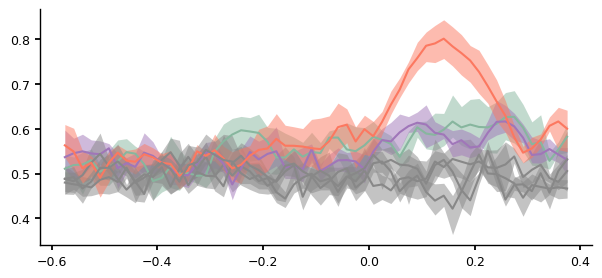

In [30]:
# see scores
fig, ax = fma.plotting.makeFigure(size=[15,7])
for r in scores:
    fma.plotting.semPlot(time,scores[r],ax=ax[0],color=isru.paperColors(r))
    fma.plotting.semPlot(time,scores_sh[r],ax=ax[0],color=isru.paperColors('shuffle'))